# GMM для кластеризации

В этом ноутбуке посмотрим:
- идея мягкой кластеризации
- разница между K-Means и GMM
- вероятности принадлежности к кластерам
- выбор количества компонент через BIC / AIC / Silhouette

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from matplotlib.patches import Ellipse

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Генерируем данные

Сделаем 3 кластера с разной формой — чтобы показать, где GMM лучше K-Means.

In [ ]:
X, y_true = make_blobs(n_samples=600, centers=3, cluster_std=0.7, random_state=42)

transform = np.array([[0.6, -0.6], [-0.4, 0.8]])
X = X @ transform

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['true_label'] = y_true
df.head()

,x1,x2,true_label
0,2.018171,-1.577407,1
1,-1.349317,-1.309079,2
2,2.410135,-1.336844,1
3,-0.308600,-2.545038,2
4,-4.853766,8.243038,0


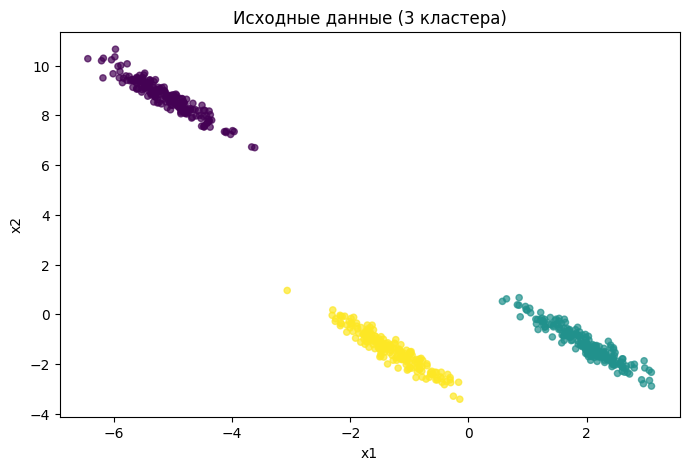

In [ ]:
plt.scatter(df['x1'], df['x2'], c=df['true_label'], cmap='viridis', s=20, alpha=0.7)
plt.title('Исходные данные (3 кластера)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

## 2. Идея мягкой кластеризации

**Жёсткая (K-Means):** точка принадлежит ровно одному кластеру.

**Мягкая (GMM):** точка принадлежит каждому кластеру с какой-то вероятностью, например `[0.7, 0.2, 0.1]`. Это удобно, когда кластеры пересекаются.

In [ ]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)

labels_gmm = gmm.predict(X)
probs = gmm.predict_proba(X)

print('Пример вероятностей для первых 5 точек:')
print(np.round(probs[:5], 3))

Пример вероятностей для первых 5 точек:
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


## 3. Визуализация вероятностей

Сделаем цвет точки = смесь RGB по вероятностям. Чем «чище» цвет — тем увереннее модель в кластере. Пограничные точки получаются «смешанными».

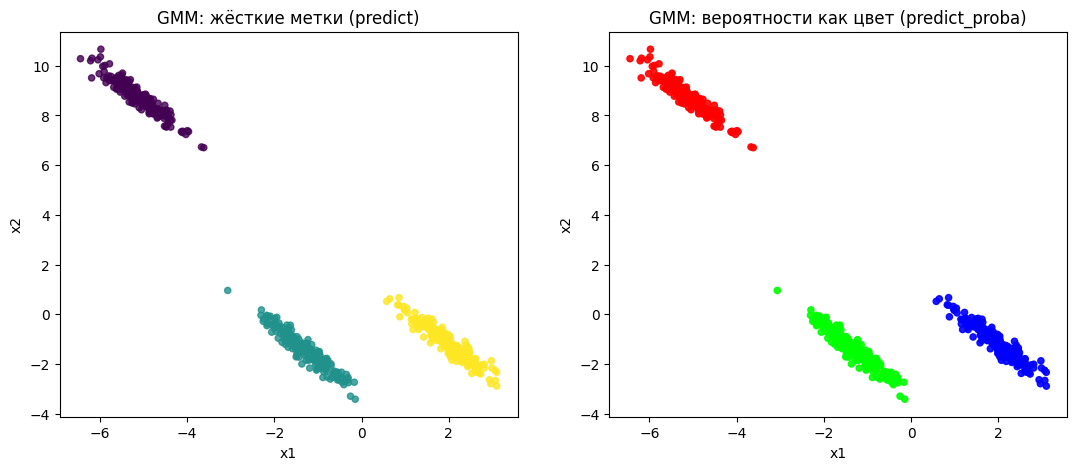

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('GMM: жёсткие метки (predict)')

axes[1].scatter(X[:, 0], X[:, 1], c=probs, s=20, alpha=0.9)
axes[1].set_title('GMM: вероятности как цвет (predict_proba)')

for ax in axes:
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.show()

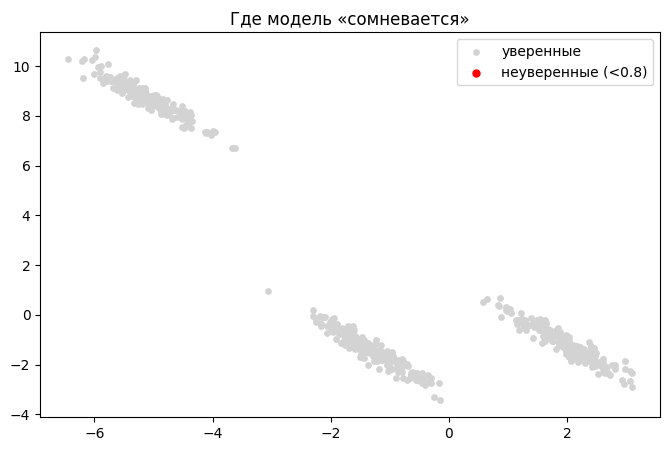

Доля неуверенных точек: 0.00%


In [ ]:
max_prob = probs.max(axis=1)
uncertain = max_prob < 0.8

plt.scatter(X[~uncertain, 0], X[~uncertain, 1], c='lightgray', s=15, label='уверенные')
plt.scatter(X[uncertain, 0], X[uncertain, 1], c='red', s=25, label='неуверенные (<0.8)')
plt.title('Где модель «сомневается»')
plt.legend(); plt.show()

print(f'Доля неуверенных точек: {uncertain.mean():.2%}')

## 4. Сравнение K-Means и GMM

K-Means считает кластеры **сферическими** одинакового размера. GMM умеет **эллиптические** кластеры разной формы — за счёт ковариационной матрицы.

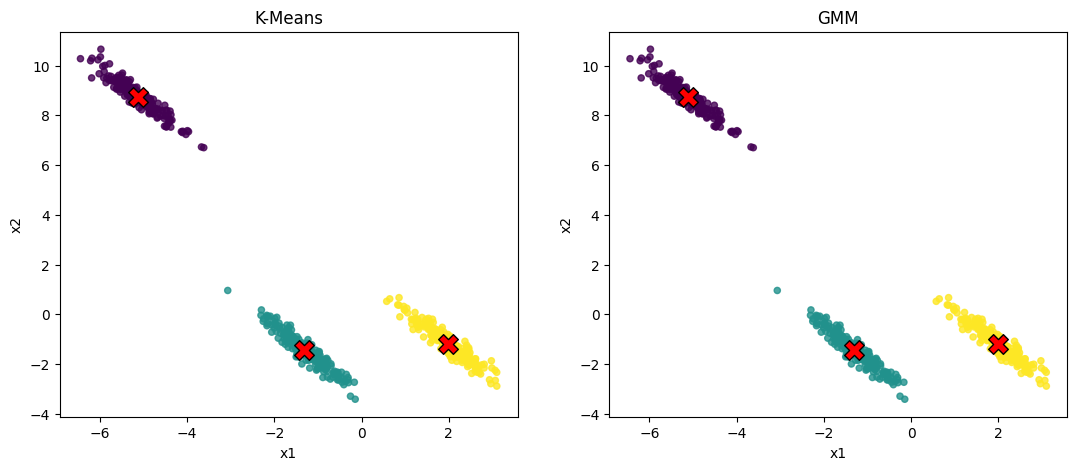

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
labels_km = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_km, cmap='viridis', s=20, alpha=0.8)
axes[0].scatter(*kmeans.cluster_centers_.T, c='red', marker='X', s=200, edgecolor='k')
axes[0].set_title('K-Means')

axes[1].scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='viridis', s=20, alpha=0.8)
axes[1].scatter(*gmm.means_.T, c='red', marker='X', s=200, edgecolor='k')
axes[1].set_title('GMM')

for ax in axes:
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.show()

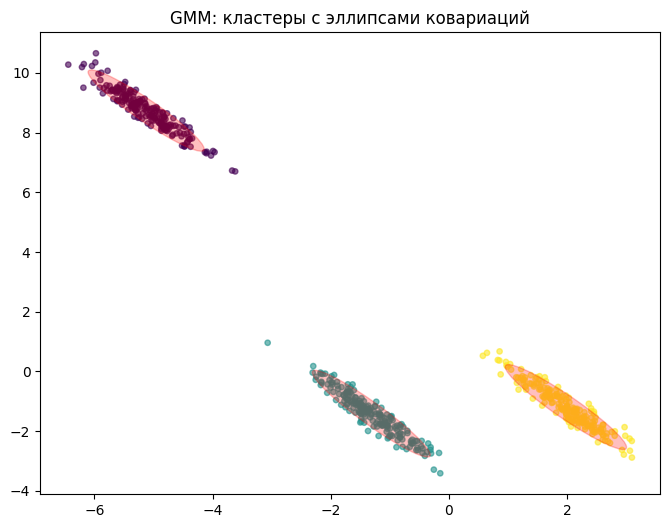

In [ ]:
def draw_ellipse(mean, cov, ax, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2 * np.sqrt(vals)
    ax.add_patch(Ellipse(mean, width, height, angle=angle, **kwargs))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='viridis', s=15, alpha=0.6)
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, ax, alpha=0.25, color='red')
ax.set_title('GMM: кластеры с эллипсами ковариаций')
plt.show()

## 5. Как выбрать число компонент?

Посчитаем три метрики для разного `n_components`:
- **BIC** (Bayesian Information Criterion) — чем **меньше**, тем лучше. Штрафует за сложность сильнее.
- **AIC** (Akaike Information Criterion) — чем **меньше**, тем лучше.
- **Silhouette** — чем **больше** (ближе к 1), тем лучше разделимость.

BIC/AIC опираются на правдоподобие модели, Silhouette — на геометрию кластеров.

In [ ]:
ks = range(2, 9)
bic, aic, sil = [], [], []

for k in ks:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X)
    bic.append(g.bic(X))
    aic.append(g.aic(X))
    sil.append(silhouette_score(X, g.predict(X)))

results = pd.DataFrame({'k': list(ks), 'BIC': bic, 'AIC': aic, 'Silhouette': sil})
results

,k,BIC,AIC,Silhouette
0,2,3524.124060,3475.757834,0.840313
1,3,2217.831771,2143.083967,0.771725
2,4,2255.327034,2154.197652,0.700624
3,5,2284.736882,2157.225922,0.660824
4,6,2318.924232,2165.031694,0.525910
5,7,2353.920659,2173.646543,0.484103
6,8,2385.785256,2179.129562,0.481092


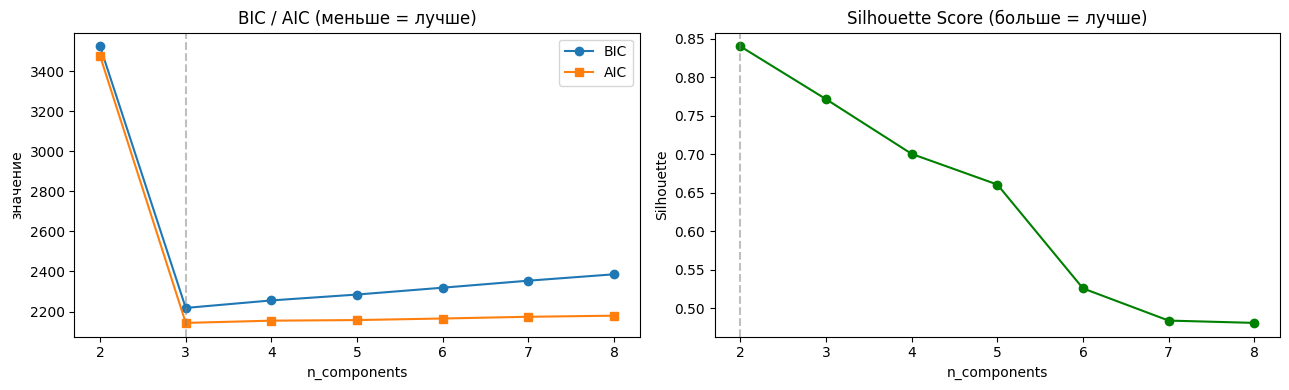

Лучшее k по BIC: 3
Лучшее k по AIC: 3
Лучшее k по Silhouette: 2


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ks, bic, 'o-', label='BIC')
axes[0].plot(ks, aic, 's-', label='AIC')
axes[0].axvline(ks[np.argmin(bic)], color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('n_components'); axes[0].set_ylabel('значение')
axes[0].set_title('BIC / AIC (меньше = лучше)')
axes[0].legend()

axes[1].plot(ks, sil, 'o-', color='green')
axes[1].axvline(ks[np.argmax(sil)], color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('n_components'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette Score (больше = лучше)')

plt.tight_layout(); plt.show()

print(f'Лучшее k по BIC: {ks[np.argmin(bic)]}')
print(f'Лучшее k по AIC: {ks[np.argmin(aic)]}')
print(f'Лучшее k по Silhouette: {ks[np.argmax(sil)]}')

#**Общий итог:**

- **GMM** даёт мягкие назначения — `predict_proba` показывает уверенность в каждой точке.
- В отличие от **K-Means**, кластеры могут быть вытянутыми эллипсами разного размера.
- **BIC/AIC** — статистические критерии для выбора числа компонент.
- На практике стоит смотреть все три и выбирать `k`, на котором BIC даёт «излом» (elbow).